# 🧠 Splotowe sieci neuronowe (CNN)

Warto przeczytać: https://www.learnpytorch.io/03_pytorch_computer_vision/

## 📍 Problem: obrazy ≠ zwykłe dane

Obraz to nie jest zwykły wektor liczb.

➡️ Obraz ma strukturę:
- piksele obok siebie są powiązane
- lokalne wzorce (np. krawędzie) mają znaczenie
- przesunięcie obiektu nie zmienia jego klasy


## ❌ Dlaczego sieci gęste zawodzą?

Sieć gęsta:
- „spłaszcza” obraz (np. 32x32x3 → 3072)
- traci informację o położeniu pikseli
- musi nauczyć się wszystkiego „od zera”

➡️ Efekt:
- ogromna liczba parametrów
- przeuczenie (overfitting)

## ✅ Jak CNN rozwiązują ten problem?

CNN:
- analizują **lokalne fragmenty obrazu**
- używają tych samych filtrów w całym obrazie
- wykrywają powtarzalne wzorce

## 🧠 Intuicja

To trochę jak wzrok człowieka:
- najpierw widzimy krawędzie
- potem kształty
- na końcu obiekty

➡️ CNN robią dokładnie to samo warstwa po warstwie

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# 📦 Dane wejściowe

Używamy CIFAR-10:
- 60 000 obrazów
- rozmiar: 32x32
- 10 klas

---

## 🎯 My wybieramy tylko 2 klasy:
- airplane
- bird

➡️ problem klasyfikacji binarnej

---

## ⚖️ Normalizacja

Dlaczego normalizujemy?
- stabilniejsze uczenie
- szybsza konwergencja

In [10]:
# Kod z poprzednich zajęć
tmp = datasets.CIFAR10("data", train=True, download=True, transform=transforms.ToTensor())

imgs = torch.stack([img for img, _ in tmp])
mean = imgs.mean(dim=(0,2,3))
std = imgs.std(dim=(0,2,3))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = datasets.CIFAR10("data", train=True, transform=transform)
val_ds = datasets.CIFAR10("data", train=False, transform=transform)

label_map = {0:0, 2:1}

def filter_ds(ds):
    return [(x, label_map[y]) for x,y in ds if y in label_map]

train_data = filter_ds(train_ds)
val_data = filter_ds(val_ds)

# 📦 DataLoader

Zamiast trenować na całym zbiorze:
➡️ dzielimy dane na batch’e

---

## ✅ Zalety:
- szybsze uczenie (GPU)
- mniejsze zużycie pamięci
- stabilniejsze gradienty

In [11]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)

# 🔍 Warstwa splotowa (Conv2d)

## 🧩 Co to jest filtr?

Filtr (kernel) to mała macierz, np.:

[ 1  0 -1 ]  
[ 1  0 -1 ]  
[ 1  0 -1 ]

Przesuwamy ją po obrazie i liczymy iloczyn skalarny.

## 🧠 Co to oznacza?

Filtr odpowiada na pytanie:
👉 „Czy w tym miejscu jest konkretny wzorzec?”

## 🎯 Przykłady filtrów

- wykrywanie pionowych krawędzi
- wykrywanie poziomych krawędzi
- rozmycie (blur)
- wyostrzenie

## 🔄 Co robi Conv2d?

1. bierze fragment obrazu (np. 3x3)
2. mnoży przez filtr
3. sumuje
4. zapisuje wynik

➡️ powstaje tzw. **mapa cech (feature map)**


## 📦 Kanały

Wejście RGB:
- 3 kanały

Każdy filtr:
- „patrzy” na wszystkie kanały naraz

Wyjście:
- tyle kanałów ile filtrów

##Przykład:
<img src="https://upload.wikimedia.org/wikipedia/commons/9/90/CNN-filter-animation-1.gif" width="800">

## 🧪 Eksperyment: klasyczne filtry

### 🔹 1. Blur (uśrednianie)

#### 📐 Kernel:

1/9 *
[1 1 1]  
[1 1 1]  
[1 1 1]

#### 🧠 Efekt:
- rozmywa obraz
- usuwa szum

### 🔹 2. Pionowe krawędzie

#### 📐 Kernel:

[-1  0  1]  
[-1  0  1]  
[-1  0  1]

#### 🧠 Efekt:
- wykrywa pionowe linie i krawędzie


### 🔹 3. Poziome krawędzie

#### 📐 Kernel:

[-1 -1 -1]  
[ 0  0  0]  
[ 1  1  1]

#### 🧠 Efekt:
- wykrywa poziome linie


### 🔹 4. Sharpen (wyostrzanie)

#### 📐 Kernel:

[ 0 -1  0]  
[-1  5 -1]  
[ 0 -1  0]

#### 🧠 Efekt:
- wzmacnia kontrasty i krawędzie


## 🎯 Wniosek

CNN uczy się dokładnie takich filtrów automatycznie:
- zamiast ręcznego projektowania
- sieć sama optymalizuje je w treningu

## ✅ Zadanie 1
Korzystając z poniższego kodu i teorii w powyższej komórce utwórz wymienione filtry (4) i sprawdź jaki mają wpływ na losowy obraz ze zbioru danych.


In [12]:
img, _ = train_data[0]
img_batch = img.unsqueeze(0)

def apply_filter(kernel, out_channels=1, in_channels=3):
    conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)

    with torch.no_grad():
        if out_channels == 1:
            conv.weight[0, 0] = kernel
        else:
            for i in range(3):
                conv.weight[i, i] = kernel

    return conv(img_batch)

def show(tensor, title, gray=False):
    plt.imshow(
        tensor.squeeze().permute(1,2,0).detach().numpy()
        if not gray else tensor[0,0].detach(),
        cmap=None if not gray else "gray"
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

In [13]:
# Przejście naszych danych przez warstwę splotową przed trenowaniem modelu
# Zinterpretuj parametry wejściowe do Conv2d
conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)

img, _ = train_data[0]

out = conv(img.unsqueeze(0))

print("Wejście:", img.unsqueeze(0).shape)
# Zinterpretuj rozmiar wyjścia z warstwy Conv2d
print("Wyjście:", out.shape)

Wejście: torch.Size([1, 3, 32, 32])
Wyjście: torch.Size([1, 16, 32, 32])


# 📏 Padding i stride

## 🔍 Problem bez paddingu

Każda operacja splotu zmniejsza obraz.

Przykład:
32x32 → 30x30 → 28x28 → ...

➡️ szybko tracimy informację

## ✅ Padding

Dodajemy ramkę zer wokół obrazu.

padding = 1 dla kernel=3:
➡️ zachowujemy rozmiar

## 🧠 Dlaczego to ważne?

- zachowujemy informacje na brzegach
- możemy budować głębsze sieci

<img src="https://upload.wikimedia.org/wikipedia/commons/0/04/Convolution_arithmetic_-_Padding_strides.gif" width="400">


## 🚶 Stride (krok)

Określa co ile pikseli przesuwamy filtr.

stride = 1 → dokładnie  
stride = 2 → „skaczemy”

<img src="https://csdl-images.ieeecomputer.org/trans/si/2020/04/figures/ko1ab-2961602.gif" width="600">


# 📉 Pooling (downsampling)

## 🔍 Problem

Obrazy są duże → dużo danych → wolne uczenie  
➡️ potrzebujemy zmniejszyć rozmiar reprezentacji

## ✅ Rozwiązanie: pooling

Pooling:
- zmniejsza rozmiar obrazu
- zachowuje najważniejsze informacje
- upraszcza dane

## 🧠 Intuicja

Pooling nie pyta:
❌ „gdzie dokładnie jest cecha?”  
✅ „czy ta cecha występuje w tym obszarze?”

---

## 🔹 Najpopularniejszy: MaxPooling

➡️ wybiera największą wartość z fragmentu


### 📐 Konkretny przykład (krok po kroku)

Wejście (4x4):

[ 1  2  0  1 ]  
[ 3  4  1  2 ]  
[ 0  1  5  6 ]  
[ 2  1  7  8 ]  


### 🔍 Dzielimy na fragmenty 2x2

#### Fragment 1:
[1 2]  
[3 4]  
➡️ max = **4**

#### Fragment 2:
[0 1]  
[1 2]  
➡️ max = **2**

#### Fragment 3:
[0 1]  
[2 1]  
➡️ max = **2**

#### Fragment 4:
[5 6]  
[7 8]  
➡️ max = **8**


### ✅ Wynik:

[ 4  2 ]  
[ 2  8 ]

### 🧠 Interpretacja

Jeśli filtr wykrywa np. krawędź:
- duża wartość = „krawędź jest tutaj”

➡️ pooling mówi:
👉 „krawędź jest gdzieś w tym regionie”

---

## 🔹 Inne rodzaje poolingów


### 1. Average Pooling

➡️ liczy średnią

#### 📐 Przykład:
[1 2]  
[3 4]  

➡️ wynik = **2.5**


#### 🧠 Co robi?
- zachowuje więcej informacji
- wygładza dane

### 2. Global Average Pooling (GAP)

➡️ średnia z całej mapy cech

#### 📐 Przykład:

[1 2]  
[3 4]  

➡️ wynik = **2.5 (jedna liczba)**


#### 🧠 Co robi?
- redukuje dane do jednej wartości
- zastępuje warstwy gęste


### 3. Global Max Pooling

➡️ największa wartość z całej mapy

#### 📐 Przykład:

[1 2]  
[3 4]  

➡️ wynik = **4**



#### 🧠 Co robi?
- sprawdza, czy cecha występuje gdziekolwiek


## ⚖️ Porównanie

| Typ pooling | Co robi | Interpretacja |
|------------|--------|--------------|
| Max        | max    | „czy cecha jest?” |
| Average    | średnia| „jak silna jest cecha?” |
| Global Avg | 1 liczba | ogólna obecność |
| Global Max | max globalny | czy gdziekolwiek występuje |



## 🎯 Co daje pooling?

- zmniejszenie rozmiaru danych
- mniej parametrów
- szybsze uczenie
- większa odporność na przesunięcia obiektów


## 🚀 W praktyce

👉 Najczęściej używany: **MaxPooling**  

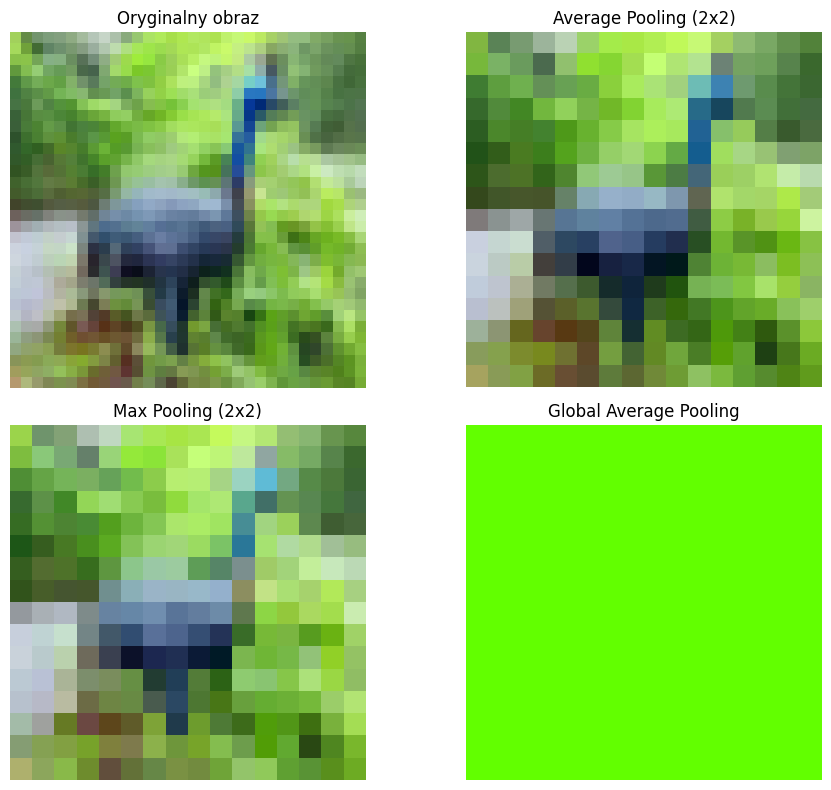

Global Average Pooling (na kanał):
tensor([-0.0758,  0.4826, -0.4271])


In [18]:
img, _ = train_data[0]  # (3, 32, 32)

# Dodajemy wymiar (wielkość wsadu)
img_batch = img.unsqueeze(0)

# Pooling
avg_pool = F.avg_pool2d(img_batch, kernel_size=2)
max_pool = F.max_pool2d(img_batch, kernel_size=2)

# Global average pooling (po wszystkich pikselach)
gap = img_batch.mean(dim=(2, 3), keepdim=True)

# Aby pokazać GAP jako obrazek → rozszerzamy do rozmiaru
gap_expanded = gap.expand_as(img_batch)

def show(img_tensor, title):
    img_np = img_tensor.squeeze().permute(1,2,0).detach().numpy()

    # Normalizacja do [0,1] dla wyświetlenia
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
show(img_batch, "Oryginalny obraz")

plt.subplot(2,2,2)
show(avg_pool, "Average Pooling (2x2)")

plt.subplot(2,2,3)
show(max_pool, "Max Pooling (2x2)")

plt.subplot(2,2,4)
show(gap_expanded, "Global Average Pooling")

plt.tight_layout()
plt.show()

# Dodatkowo: wartości GAP
print("Global Average Pooling (na kanał):")
print(gap.squeeze())

In [15]:
# Na naszych danych
pool = nn.MaxPool2d(2)

out_pool = pool(out)

print(out_pool.shape)

torch.Size([1, 16, 16, 16])


# 🧱 Architektura CNN

Conv → F. aktywacji → Pool → Conv → F. aktywacji → Pool → Flatten → Wartwa gęsta liniowa

## 🔄 Ogólny schemat CNN

CNN składa się z dwóch głównych części:

### 1. 🔍 Ekstraktor cech (feature extractor)
- Conv2d
- Funkcje aktywacji (ReLU / Tanh)
- Pooling

👉 Zadanie:
„Co jest na obrazie?”

### 2. 🎯 Klasyfikator (classifier)
- Flatten
- Linear (Fully Connected)

👉 Zadanie:
„Co to jest?”

---

## 📉 Po co Flatten?

### 🧠 Problem

Po warstwach splotowych mamy dane 3D:

👉 (kanały, wysokość, szerokość)  
np. (64, 8, 8)

Warstwa Linear nie rozumie danych 3D.

Oczekuje:

👉 wektora 1D (np. 4096)

### ✅ Rozwiązanie: Flatten

Flatten:
➡️ zamienia tensor 3D → 1D

### 📐 Przykład:

(64, 8, 8)  
➡️ 64 × 8 × 8 = **4096**

➡️ (4096)

## 🧠 Po co warstwa Linear na końcu?

### 🎯 Zadanie Linear

Warstwa Linear:
👉 podejmuje decyzję klasyfikacyjną

---

## 🔗 Cały przepływ danych

### 🟢 1. Obraz
(3, 32, 32)

⬇️

### 🟡 2. Conv + Pool
➡️ mapy cech

(64, 8, 8)

⬇️

### 🔵 3. Flatten
➡️ wektor

(4096)

⬇️

### 🔴 4. Linear
➡️ decyzja

(2 klasy)

## ✅ Zadanie 2
Zdefiniuj sieć splotową tworząc klasę `Net`. Niech posiada warstwy (podane jako atrybuty klasy `Net` w konstruktorze):
- `conv1` - 3 kanały wejściowe, 16 filtrów 3x3, padding=1
- `conv2` - 16 kanałów wejściowych, 8 filtrów 3x3, padding=1
- po obu tych warstwach: funkcje aktywacji tangens hiperboliczny (`act1` i `act2`)
- po funkcjach aktywacji: warstwy typu max pooling 2x2 (`pool1`, `pool2`)
- na końcu "sieć gęstą" złożoną z dwóch warstw `nn.Linear` (`fc1`, `fc2`) rozdzielonych  funkcją aktywacji (`act3`)

Zastąp wszystkie wystąpienia `None` kodem.


Zastanów się, jaki musi być rozmiar wejścia do "sieci gęstej" i rozmiar wyjścia z niej. Przyjmij "pośredni" rozmiar w sieci gęstej (wyjście z pierwszej warstwy `Linear` i wejście do drugiej) równy 32.

Następnie zdefiniuj, jak dane wejściowe (argument `x`) mają być przetwarzane przez sieć w kroku "w przód", tj. uzupełnij implementację metody `self.forward()`.

In [16]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # uzupełnij zgodnie z opisem powyżej dla conv1, a potem dopisz kolejne podmoduły (warstwy)
        self.conv1 = None
        ### itd.

    def forward(self, x):
        # zaimplementuj logikę kroku "w przód", dla wygody w kilku liniach
        out = None
        return out

# 📉 Funkcja straty

Używamy:
➡️ CrossEntropyLoss


## 🧠 Dlaczego?
- do klasyfikacji
- łączy softmax + log loss


In [19]:
model = Net().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

ValueError: optimizer got an empty parameter list

# 🔁 Trening modelu

## ⚙️ model.train() vs model.eval()

W PyTorch tryb modelu ma ogromne znaczenie podczas uczenia i testowania.

### 🔁 model.train()

#### 📍 Kiedy używamy?

Podczas treningu modelu.

#### 🧠 Co się dzieje?

`model.train()`:
- aktywuje uczenie warstw
- włącza mechanizmy regularizacji

#### 🔍 Co to oznacza w praktyce?

- Dropout → LOSOWO wyłącza neurony
- BatchNorm → aktualizuje statystyki (mean, variance)

### 📊 model.eval()

#### 📍 Kiedy używamy?

Podczas:
- walidacji
- testowania
- predykcji

#### 🧠 Co się zmienia?

`model.eval()`:
- wyłącza dropout
- zamraża BatchNorm

#### 🎯 Cel

👉 uzyskać stabilne i powtarzalne wyniki

#### ⚠️ Najważniejsza różnica

| Tryb | Dropout | BatchNorm | Cel |
|------|--------|-----------|-----|
| train() | ON | update | uczenie |
| eval()  | OFF | fixed | test / inferencja |

In [20]:
def train(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# 📊 Metryki ewaluacji modelu

Sama dokładność nie zawsze wystarcza.

Dlatego użyjemy kilku metryk:

## 🎯 Dokładność
➡️ ile przykładów model klasyfikuje poprawnie

## 🎯 Precyzja
➡️ ile z przewidzianych pozytywów było poprawnych

## 🎯 Czułość
➡️ ile prawdziwych pozytywów model wykrył

## 🎯 F1-score
➡️ kompromis między dokładnością i czułością

In [ ]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print("📊 METRYKI MODELU")
    print("-------------------")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    # print("\nConfusion Matrix:")
    # print(cm)

In [ ]:
for epoch in range(10):
    loss = train(model, train_loader)
    print(f"Epoch {epoch}")
evaluate(model, val_loader)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
📊 METRYKI MODELU
-------------------
Accuracy : 0.9010
Precision: 0.9195
Recall   : 0.8790
F1-score : 0.8988


(0.901,
 0.9194560669456067,
 0.879,
 0.8987730061349694,
 array([[923,  77],
        [121, 879]]))

In [21]:
def show_model_pred(model, dataset, idx=0):
    model.eval()
    img, label = dataset[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_label = pred.argmax(1).item()

    show(img, f"True: {label}, Pred: {pred_label}")


show_model_pred(model, val_data, 10)

AttributeError: 'NoneType' object has no attribute 'argmax'

## ✅ Zadanie 3
1. Zaimplementuj kod, który pozwoli podejrzeć predykcje, które są niezgodne z prawdziwą etykietą obrazu.
2. Przeanalizuj te obrazy i wyciągnij wnioski.

## ✅ Zadanie 4 - **poeksperymentuj** z poniższymi narzędzami, przyjrzyj się wpływowi parametrów wejściowych (**opisz wszystkie parametry w sprawozdaniu**) na rozmiar wyjścia z wartwy.
- obliczanie rozmiaru wyjścia z wartwy splotowej: https://madebyollin.github.io/convnet-calculator/
- symulacja działania filtru przy zmianach padding i stride: https://sesen.ai/convolution-visualizer

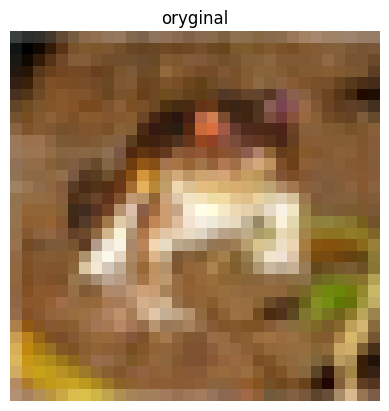

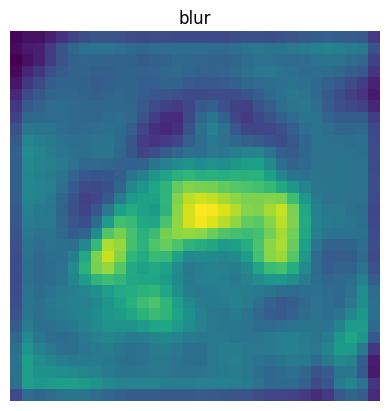

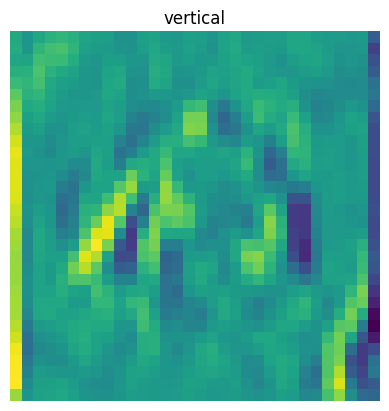

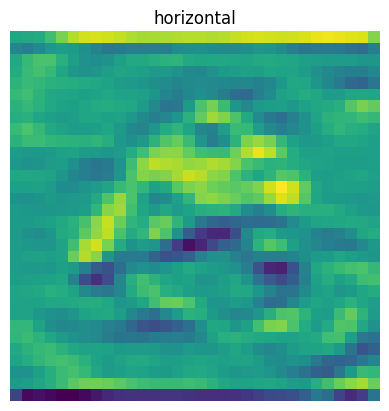

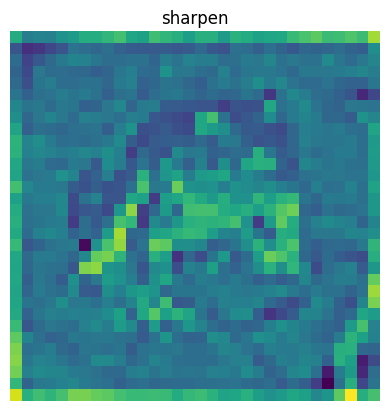

In [29]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

# transformacja do tensora
transform = transforms.ToTensor()

# pobranie danych
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# losowy obraz
image, label = trainset[0]

# dodanie batch dimension
image_batch = image.unsqueeze(0)

# funkcja do pokazania obrazu
def show_tensor(img, title='image'):
    img = img.squeeze(0)
    img = img.permute(1, 2, 0)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# blur
blur_kernel = torch.tensor([
    [[1/9,1/9,1/9],
     [1/9,1/9,1/9],
     [1/9,1/9,1/9]]
], dtype=torch.float32)

# pionowe krawedzie
vertical_kernel = torch.tensor([
    [[-1,0,1],
     [-1,0,1],
     [-1,0,1]]
], dtype=torch.float32)

# poziome krawedzie
horizontal_kernel = torch.tensor([
    [[-1,-1,-1],
     [0,0,0],
     [1,1,1]]
], dtype=torch.float32)

# sharpen
sharpen_kernel = torch.tensor([
    [[0,-1,0],
     [-1,5,-1],
     [0,-1,0]]
], dtype=torch.float32)

# funkcja do tworzenia filtru dla rgb
def make_kernel(kernel):
    return kernel.repeat(3,1,1).unsqueeze(0)

kernels = {
    'blur': make_kernel(blur_kernel),
    'vertical': make_kernel(vertical_kernel),
    'horizontal': make_kernel(horizontal_kernel),
    'sharpen': make_kernel(sharpen_kernel)
}

# pokazanie oryginalu
show_tensor(image_batch, 'oryginal')

# zastosowanie filtrow
for name, kernel in kernels.items():
    output = F.conv2d(image_batch, kernel, padding=1)
    show_tensor(output.detach(), name)

## Odpowiedzi
Co robi blur?

Rozmywa obraz i usuwa drobne szczegóły.

Co robi filtr pionowy?

Wykrywa pionowe krawędzie.

Co robi filtr poziomy?

Wykrywa poziome krawędzie.

Co robi sharpen?

Wyostrza obraz i podkreśla szczegóły.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # pierwsza warstwa conv
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # druga warstwa conv
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=8,
            kernel_size=3,
            padding=1
        )

        # aktywacje
        self.act1 = nn.Tanh()
        self.act2 = nn.Tanh()

        # pooling
        self.pool1 = nn.MaxPool2d(2)
        self.pool2 = nn.MaxPool2d(2)

        # flatten: 32x32 -> 16x16 -> 8x8
        # 8 kanalow * 8 * 8 = 512
        self.fc1 = nn.Linear(512, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):

        # conv1
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        # conv2
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        # flatten
        x = torch.flatten(x, 1)

        # dense
        x = self.fc1(x)
        x = torch.tanh(x)
        x = self.fc2(x)

        return x

model = Net()
print(model)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act1): Tanh()
  (act2): Tanh()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)


## Odpowiedzi
Dlaczego używamy pooling?

Zmniejsza rozmiar danych i przyspiesza uczenie.

Po co flatten?

Zamienia dane 3D na wektor dla warstw liniowych.

Dlaczego Conv2d jest lepsze od Linear dla obrazow?

Bo zachowuje informacje przestrzenne.

# Przygotowanie danych i DataLoader

In [24]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# airplane = 0
# bird = 2

train_indices = [i for i, (_, label) in enumerate(trainset)
                 if label in [0,2]]

test_indices = [i for i, (_, label) in enumerate(testset)
                if label in [0,2]]

train_subset = torch.utils.data.Subset(trainset, train_indices)
test_subset = torch.utils.data.Subset(testset, test_indices)

trainloader = DataLoader(train_subset, batch_size=64, shuffle=True)
testloader = DataLoader(test_subset, batch_size=64, shuffle=False)

# Funkcja straty i optimizer

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Odpowiedzi
Dlaczego CrossEntropyLoss?

Bo jest przeznaczony do klasyfikacji.

Dlaczego Adam?

Szybko i stabilnie się uczy.

# Trening modelu

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        # bird zamieniamy na 1
        labels = (labels == 2).long()

        # zerowanie gradientu
        optimizer.zero_grad()

        # forward
        outputs = model(images)

        # loss
        loss = criterion(outputs, labels)

        # backward
        loss.backward()

        # update wag
        optimizer.step()

        running_loss += loss.item()

    print(f'epoch {epoch+1}, loss={running_loss:.4f}')

epoch 1, loss=68.8096
epoch 2, loss=55.2019
epoch 3, loss=51.3998
epoch 4, loss=48.8731
epoch 5, loss=46.2475


## Odpowiedzi
Po co optimizer.zero_grad()?

Gradienty w PyTorch się sumują.

Po co model.train()?

Włącza tryb treningowy.

# Ewaluacja modelu

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        labels = (labels == 2).long()

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print('accuracy:', acc)
print('precision:', prec)
print('recall:', rec)
print('f1:', f1)

accuracy: 0.868
precision: 0.8498098859315589
recall: 0.894
f1: 0.8713450292397661


## Odpowiedzi
Accuracy

Ile predykcji jest poprawnych.

Precision

Ile przewidzianych pozytywów było poprawnych.

Recall

Ile prawdziwych pozytywów model wykrył.

F1-score

Srednia precision i recall.

# Zadanie 3 — błędne predykcje

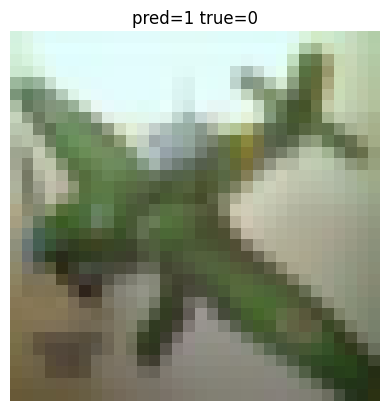

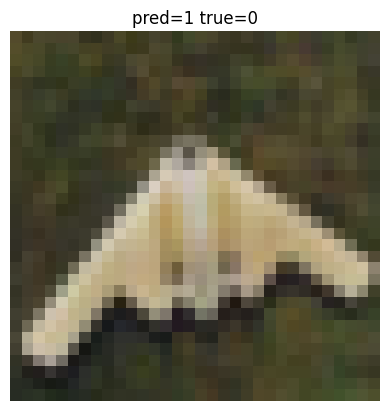

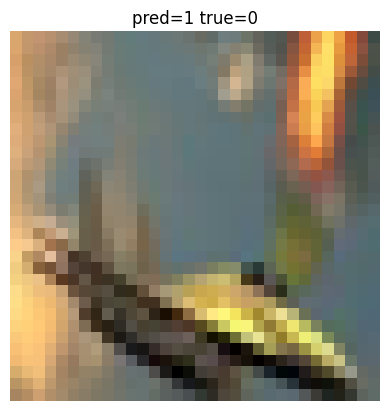

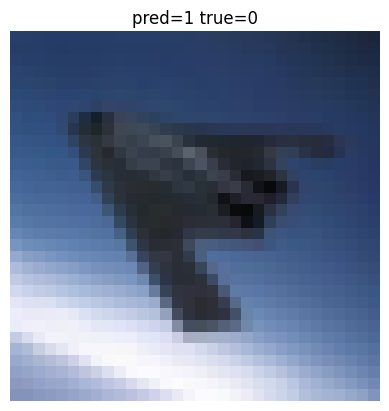

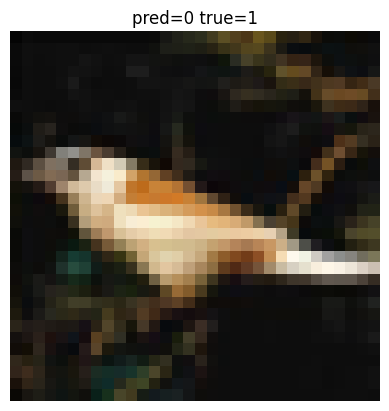

In [28]:
import matplotlib.pyplot as plt

model.eval()

shown = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = (labels == 2).long().to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        wrong = preds != labels

        wrong_images = images[wrong]
        wrong_preds = preds[wrong]
        wrong_labels = labels[wrong]

        for i in range(len(wrong_images)):

            img = wrong_images[i].cpu()
            img = img.permute(1,2,0)

            plt.imshow((img * 0.5 + 0.5))
            plt.title(f'pred={wrong_preds[i].item()} true={wrong_labels[i].item()}')
            plt.axis('off')
            plt.show()

            shown += 1

            if shown >= 5:
                break

        if shown >= 5:
            break

## Wnioski

Model myli obrazy:

o podobnych kolorach
z podobnym tłem
z małym lub niewyraźnym obiektem

Najtrudniejsze są obrazy o niskiej jakości lub nietypowym kącie.

# Zadanie 4 — padding i stride

## Odpowiedzi
Padding

Dodaje ramkę zer wokół obrazu.

Stride

Określa o ile pikseli przesuwa się filtr.

Wpływ stride

Większy stride:

mniejszy obraz wyjściowy
szybsze obliczenia
większa utrata informacji
Wpływ padding

Padding:

zachowuje rozmiar obrazu
poprawia analizę brzegów obrazuWnioski





# WNIOSKI
Podczas laboratorium poznano działanie sieci CNN oraz warstw Conv2d i MaxPooling. Zrozumiano wpływ filtrów na obraz oraz znaczenie padding i stride. Zaimplementowano własną sieć CNN do klasyfikacji obrazów i przeprowadzono trening modelu przy użyciu PyTorch. Obliczono metryki jakości oraz przeanalizowano błędne predykcje modelu.